In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


In [11]:
data = pd.read_csv('data.csv')

X = data['X']
Y = data['Y']

print(data.head())


   X          Y
0  1   3.993428
1  2   4.723471
2  3   8.295377
3  4  12.046060
4  5  10.531693


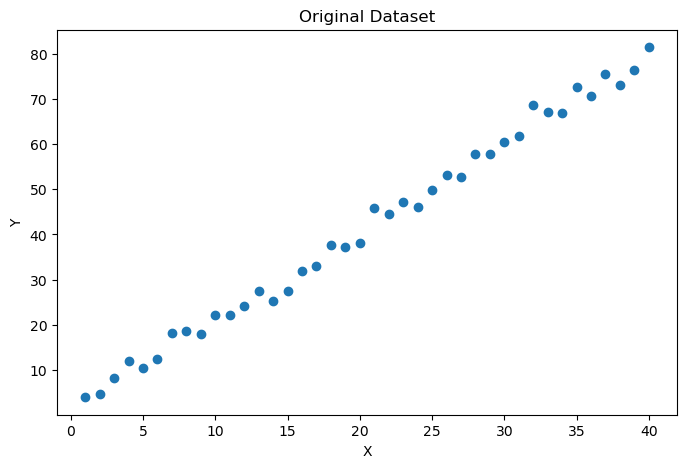

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(X, Y)

plt.title('Original Dataset')
plt.xlabel('X')
plt.ylabel('Y')

plt.show()


In [13]:
def manual_linear_regression(X_train, Y_train):
    X_mean = np.mean(X_train)
    Y_mean = np.mean(Y_train)

    num = 0
    den = 0

    for i in range(len(X_train)):
        num += (X_train.iloc[i] - X_mean) * (Y_train.iloc[i] - Y_mean)
        den += (X_train.iloc[i] - X_mean) ** 2

    m = num / den
    c = Y_mean - m * X_mean

    return m, c


In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 32
Testing samples: 8


In [15]:
m, c = manual_linear_regression(X_train, Y_train)

Y_pred = m * X_test + c

print(f"Slope (m): {m:.4f}")
print(f"Intercept (c): {c:.4f}")


Slope (m): 1.9659
Intercept (c): 1.5103


In [16]:
MSE = mean_squared_error(Y_test, Y_pred)
R2 = r2_score(Y_test, Y_pred)

print("80-20 Split Results:")
print(f"Slope (m): {m:.4f}")
print(f"Intercept (c): {c:.4f}")
print(f"MSE: {MSE:.4f}")
print(f"Accuracy (R² Score): {R2:.4f}")


80-20 Split Results:
Slope (m): 1.9659
Intercept (c): 1.5103
MSE: 3.4615
Accuracy (R² Score): 0.9898


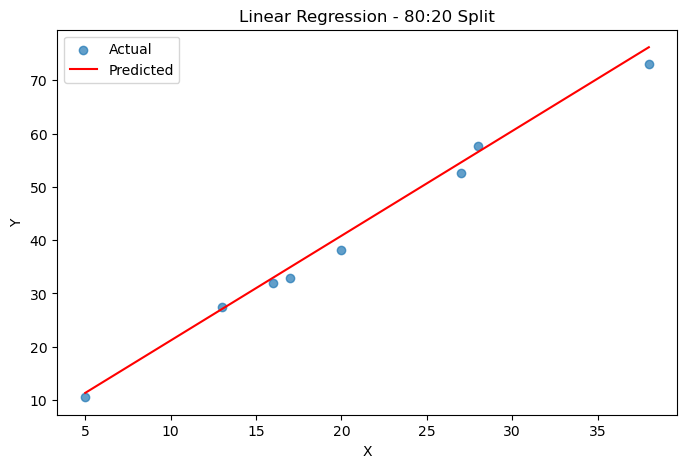

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test,
    Y_test,
    alpha=0.7,
    label='Actual'
)

plt.plot(
    [min(X_test), max(X_test)],
    [
        m * min(X_test) + c,
        m * max(X_test) + c
    ],
    color='red',
    label='Predicted'
)

plt.title('Linear Regression - 80:20 Split')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.show()


In [18]:
print("Performance Analysis")
print("=" * 40)

if R2 > 0.8:
    print("Model shows GOOD performance (R² > 0.8)")
elif R2 > 0.6:
    print("Model shows MODERATE performance")
else:
    print("Model shows POOR performance")

print(f"MSE = {MSE:.4f}")
print(f"R² Score = {R2:.4f}")


Performance Analysis
Model shows GOOD performance (R² > 0.8)
MSE = 3.4615
R² Score = 0.9898
